# 3.1.3 Ejercicios: Grafos aleatorios de Erdős–Rényi

Ana Luisa Llamas Martinez

ENES-Juriquilla

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import random
from scipy.stats import binom, poisson
import numpy as np
from scipy.stats import binom, poisson

def grafo_erdos_renyi(N, p, seed=None):
    """
    Genera una realización del grafo aleatorio G(N,p).
    """
    if seed is not None:
        random.seed(seed)

    G = nx.Graph()
    G.add_nodes_from(range(N))

    for i in range(N):
        for j in range(i + 1, N):
            if random.random() < p:
                G.add_edge(i, j)

    return G

def dibujar_realizaciones(N, p, n_realizaciones=3, layout="spring", seed_base=10):
    """
    Dibuja varias realizaciones de G(N,p) con los mismos parámetros.
    """
    fig, axes = plt.subplots(1, n_realizaciones, figsize=(5 * n_realizaciones, 5))

    if n_realizaciones == 1:
        axes = [axes]

    for k, ax in enumerate(axes):
        G = grafo_erdos_renyi(N, p, seed=seed_base + k)

        # Elegir layout
        if layout == "circular":
            pos = nx.circular_layout(G)
        else:
            pos = nx.spring_layout(G, seed=seed_base + k)

        L = G.number_of_edges()

        nx.draw_networkx_nodes(
            G, pos, ax=ax,
            node_size=300,
            node_color="#7a4fa3"
        )
        nx.draw_networkx_edges(
            G, pos, ax=ax,
            edge_color="limegreen",
            width=1.5
        )

        ax.set_title(f"Realización {k+1}\nN={N}, p={p}, L={L}", fontsize=12)
        ax.set_axis_off()

    plt.tight_layout()
    plt.show()

def dibujar_realizaciones_con_esperanza(N, p, n_realizaciones=3, layout="spring", seed_base=10):
    """
    Dibuja varias realizaciones de G(N,p) con los mismos parámetros.
    """
    fig, axes = plt.subplots(1, n_realizaciones, figsize=(5 * n_realizaciones, 5))

    if n_realizaciones == 1:
        axes = [axes]
    L_esperado = p * N * (N-1) / 2
    for k, ax in enumerate(axes):
        G = grafo_erdos_renyi(N, p, seed=seed_base + k)

        # Elegir layout
        if layout == "circular":
            pos = nx.circular_layout(G)
        else:
            pos = nx.spring_layout(G, seed=seed_base + k)

        L = G.number_of_edges()

        nx.draw_networkx_nodes(
            G, pos, ax=ax,
            node_size=300,
            node_color="#7a4fa3"
        )
        nx.draw_networkx_edges(
            G, pos, ax=ax,
            edge_color="limegreen",
            width=1.5
        )

        ax.set_title(f"Realización {k+1}\nN={N}, p={p}, L={L}\nE[L]={L_esperado:.2f}", fontsize=12)
        ax.set_axis_off()

    plt.tight_layout()
    plt.show()

def simular_numero_aristas(N, p, n_sim=1000):
    valores_L = []
    for s in range(n_sim):
        G = grafo_erdos_renyi(N,p, seed=s)
        valores_L.append(G.number_of_edges())

    return valores_L

## Ejercicio 1. Número de aristas en una realización

Considere un grafo aleatorio G(N,p) con N=20 y p=0.2.

- Genere una realización del grafo.
- Calcule el número de aristas observadas L
- Calcule el número esperado de aristas:

- Compare el valor observado con el valor esperado.
- Dibuje la red obtenida.

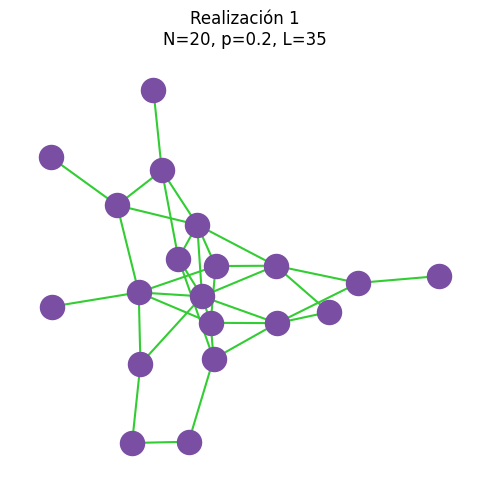

Número esperado de aristas: 38.0


In [ ]:
N1 = 20
p1 = 0.2

G = dibujar_realizaciones(N1, p1, n_realizaciones=1, layout="spring")

L_esperado1 = p1*N1*(N1 - 1)/2

print("Número esperado de aristas:", L_esperado1)

**Pregunta conceptual.**

¿Por qué el número de aristas observado no tiene por qué coincidir exactamente con ⟨L⟩?

**R =** Por la variabilidad estadística.


## Ejercicio 2. Variabilidad del número de aristas.

Fije N=30 y p=0.1.

- Genere 100 realizaciones independientes del grafo aleatorio G(N,p).
- Para cada realización, calcule el número de aristas L.
- Construya un histograma de los valores obtenidos.
- Calcule el promedio muestral de L.
- Compare este promedio con el valor teórico:

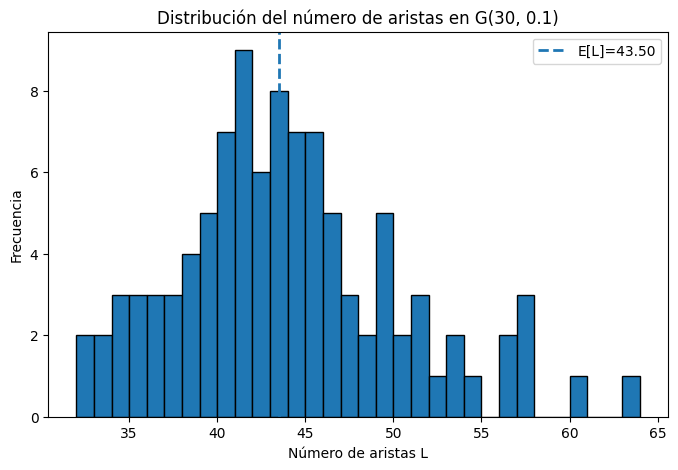

El promedio de L esperado es 43.5, mientras que la L teórica es 43.54


In [ ]:
N2 = 30
p2 = 0.1

valores_L2 = simular_numero_aristas(N2,p2, n_sim=100)
L_esperado2 = p2*N2*(N2-1)/2
L_muestral2 = np.mean(valores_L2)

plt.figure(figsize=(8,5))
plt.hist(valores_L2, bins=range(min(valores_L2), max(valores_L2)+2), edgecolor = "black")
plt.axvline(L_esperado2, linestyle= "--", linewidth=2, label=f"E[L]={L_esperado2:.2f}")
plt.xlabel("Número de aristas L")
plt.ylabel("Frecuencia")
plt.title(f"Distribución del número de aristas en G({N2}, {p2})")
plt.legend()
plt.show()

print(f"El promedio de L esperado es {L_esperado2}, mientras que la L teórica es {L_muestral2}")

**Pregunta conceptual.**

Explique por qué, aun cuando los parámetros N y p son los mismos, distintas realizaciones pueden tener diferente número de aristas.

 **R=** Porque solo fijamos N y p para determinar la media y la varianza, en cambio, el número de aristas fluctúan de acuerdo a estos dos últimos valores.

## Ejercicio 3. Grado promedio.

Considere un grafo aleatorio G(N, p) con N=100 y p=0.05.

- Genere una realización del grafo.
- Calcule el grado de cada nodo.
- Obtenga el grado promedio observado.
- Compare con el valor teórico:
- Verifique numéricamente que *** donde L es el número de aristas observadas.

In [ ]:
N3 = 100
p3 = 0.05

G3 = grafo_erdos_renyi(N3, p3, seed=None)

grados_dict3 = dict(G3.degree())

for nodo, grado in grados_dict3.items():
    print(f" El nodo {nodo} tiene {grado} grados.")

 El nodo 0 tiene 5 grados.
 El nodo 1 tiene 4 grados.
 El nodo 2 tiene 8 grados.
 El nodo 3 tiene 5 grados.
 El nodo 4 tiene 6 grados.
 El nodo 5 tiene 4 grados.
 El nodo 6 tiene 3 grados.
 El nodo 7 tiene 4 grados.
 El nodo 8 tiene 4 grados.
 El nodo 9 tiene 5 grados.
 El nodo 10 tiene 7 grados.
 El nodo 11 tiene 6 grados.
 El nodo 12 tiene 5 grados.
 El nodo 13 tiene 8 grados.
 El nodo 14 tiene 6 grados.
 El nodo 15 tiene 4 grados.
 El nodo 16 tiene 4 grados.
 El nodo 17 tiene 5 grados.
 El nodo 18 tiene 8 grados.
 El nodo 19 tiene 4 grados.
 El nodo 20 tiene 4 grados.
 El nodo 21 tiene 2 grados.
 El nodo 22 tiene 2 grados.
 El nodo 23 tiene 6 grados.
 El nodo 24 tiene 10 grados.
 El nodo 25 tiene 1 grados.
 El nodo 26 tiene 5 grados.
 El nodo 27 tiene 7 grados.
 El nodo 28 tiene 9 grados.
 El nodo 29 tiene 6 grados.
 El nodo 30 tiene 4 grados.
 El nodo 31 tiene 1 grados.
 El nodo 32 tiene 5 grados.
 El nodo 33 tiene 4 grados.
 El nodo 34 tiene 3 grados.
 El nodo 35 tiene 5 grados.
 

In [ ]:
#grado promedio observado
grados3 = [d for n, d in G3.degree()]

grado_prom_obs3 = sum(grados3) / N3

#grado promedio teórico
grado_prom_teo3 = p3 * (N3 -1)

print(f"El grado promedio observado es {grado_prom_obs3}, mientras que el grado promedio teórico es {grado_prom_teo3}")

El grado promedio observado es 4.64, mientras que el grado promedio teórico es 4.95


In [ ]:
#verificación numérica

2 * G3.number_of_edges() / N3

4.64

**Pregunta conceptual.**

¿Por qué el promedio de grados está relacionado con el número de aristas mediante la expresión $\frac{2L}{N}$?

**R=** Porque el número total de grados es dos veces el número de aristas, por ende, solo sustituimos en la ecuación de grado promedio.

## Ejercicio 4. Distribución de grados.

Considere un grafo aleatorio G(N, p) con N = 100 y p = 0.05.

- Genere una realización del grafo.
- Calcule la secuencia de grados.
- Haga un histograma de la distribución de grados.
- Calcule el grado promedio observado.
- Compare visualmente la distribución obtenida con una distribución binomial.

In [ ]:
N4 = 100
p4 = 0.05

#generación del grafo
G4 = grafo_erdos_renyi(N4, p4, seed=None)

#secuencia de grados
grados4 = [d for n, d in G4.degree()]

print("La secuencia de grados es:", grados4)

La secuencia de grados es: [3, 3, 3, 5, 3, 3, 3, 2, 7, 3, 2, 7, 5, 5, 4, 5, 3, 3, 6, 7, 9, 13, 7, 4, 8, 4, 4, 5, 6, 6, 6, 4, 4, 10, 2, 9, 4, 3, 5, 3, 6, 7, 4, 5, 5, 6, 6, 4, 8, 8, 5, 2, 2, 5, 6, 3, 5, 2, 8, 4, 8, 5, 7, 8, 5, 2, 4, 4, 7, 4, 4, 6, 3, 5, 4, 3, 3, 7, 3, 5, 7, 6, 7, 7, 3, 8, 9, 7, 1, 7, 3, 5, 6, 2, 3, 0, 5, 8, 3, 5]


In [ ]:
#grado promedio observado

grado_prom_obs3 = sum(grados3) / N3
print("El grado promedio observado es", grado_prom_obs3)

El grado promedio observado es 4.64


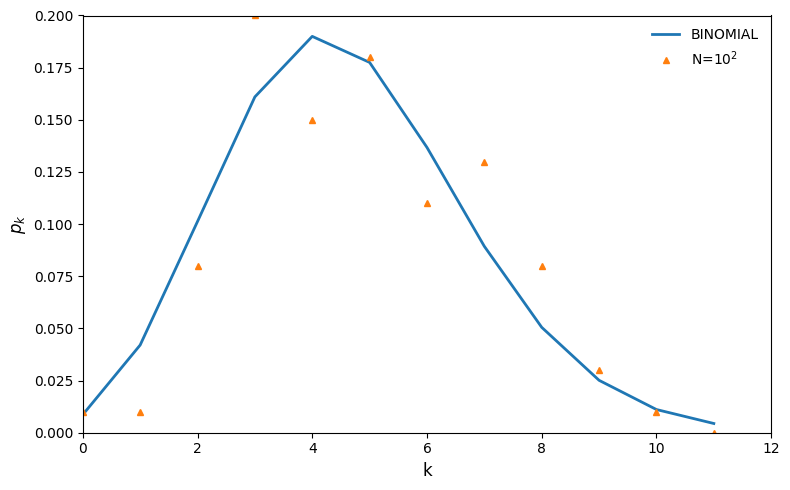

In [ ]:
# Parámetro: grado medio deseado
k_mean = grado_prom_obs3

# Valores de N
Ns = [100]

# Rango de k para graficar
k_vals = np.arange(0, 12)

plt.figure(figsize=(8, 5))

# --- Curva binomial teórica ---
# Para comparar, usamos N grande (por ejemplo 10^4)
N_ref = 100
p_ref = k_mean / (N_ref - 1)
binom_pmf = binom.pmf(k_vals, N_ref - 1, p_ref)
plt.plot(k_vals, binom_pmf, '-', lw=2, label='BINOMIAL')

# --- "Datos" para distintos N ---
markers = ['^']

for N, marker in zip(Ns, markers):
    p = k_mean / (N - 1)

    probs = np.array([(grados4 == k).mean() for k in k_vals])

    plt.plot(
        k_vals, probs,
        linestyle='None',
        marker=marker,
        markersize=5,
        label=fr'N=$10^{int(np.log10(N))}$'
    )

plt.xlabel('k', fontsize=12)
plt.ylabel(r'$p_k$', fontsize=12)
plt.xlim(0, 12)
plt.ylim(0, 0.20)
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig("distribucion_grado_red_aleatoria.png", dpi=300)
plt.show()

**Pregunta conceptual.**

¿Por qué en el modelo de Erdős–Rényi la distribución de grados se modela mediante una distribución binomial?

**R=** Porque cada nodo tiene probabilidad p de conectarse con otro nodo (éxito) o no. Y, por definición, éstos sigue una distribución binomial.

## EJERCICIO 5. Efecto de la probabilidad de conexión.

Fije N = 50 y considere los valores p = 0.01, 0.05, 0.1, 0.2.
 
- Genere una realización del grafo aleatorio G(N, p) para cada valor de  p.
- Para cada grafo, calcule:
    - el número de aristas L,
    - el grado promedio observado,
    - el número de componentes conexas.
- Dibuje las cuatro redes obtenidas.
- Organice los resultados en una tabla.

El número de aristas es: 15
El grado promedio observado: 0.6
El número de componentes conexas es: 35


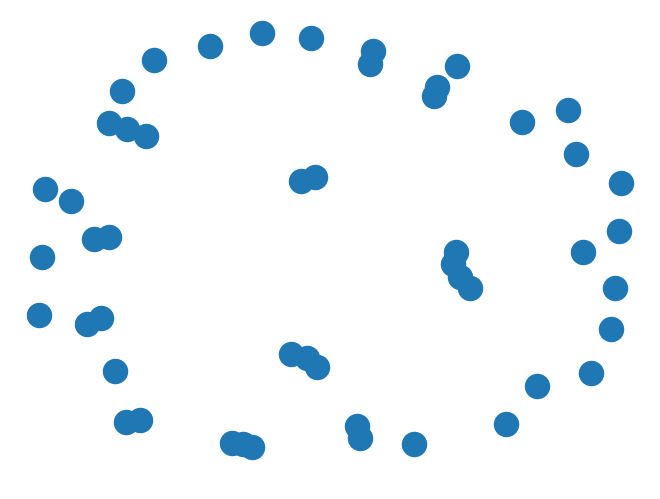

In [ ]:
N5 = 50
p5 = [0.01, 0.05, 0.1, 0.2]

#Grafo 1
g1 = grafo_erdos_renyi(N5, p5[0], 42)

print("El número de aristas es:", g1.number_of_edges())

print("El grado promedio observado:", (2 * g1.number_of_edges() / g1.number_of_nodes()))

print("El número de componentes conexas es:", len(list(nx.connected_components(g1))))

nx.draw(g1)

El número de aristas es: 55
El grado promedio observado: 2.2
El número de componentes conexas es: 6


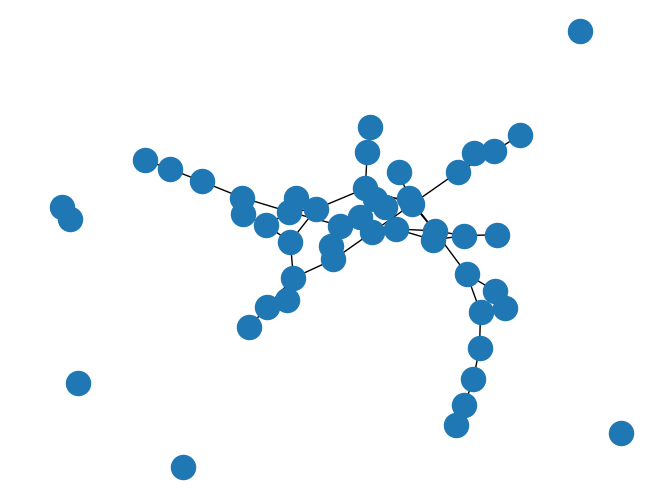

In [ ]:
#Grafo 2
g2 = grafo_erdos_renyi(N5, p5[1], 42)

print("El número de aristas es:", g2.number_of_edges())

print("El grado promedio observado:", (2 * g2.number_of_edges() / g2.number_of_nodes()))

print("El número de componentes conexas es:", len(list(nx.connected_components(g2))))

nx.draw(g2)

El número de aristas es: 120
El grado promedio observado: 4.8
El número de componentes conexas es: 1


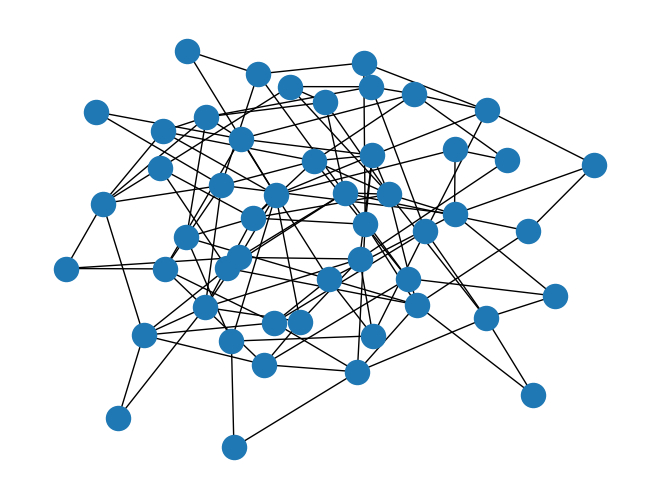

In [ ]:
#Grafo 3
g3 = grafo_erdos_renyi(N5, p5[2], 42)

print("El número de aristas es:", g3.number_of_edges())

print("El grado promedio observado:", (2 * g3.number_of_edges() / g3.number_of_nodes()))

print("El número de componentes conexas es:", len(list(nx.connected_components(g3))))

nx.draw(g3)

El número de aristas es: 232
El grado promedio observado: 9.28
El número de componentes conexas es: 1


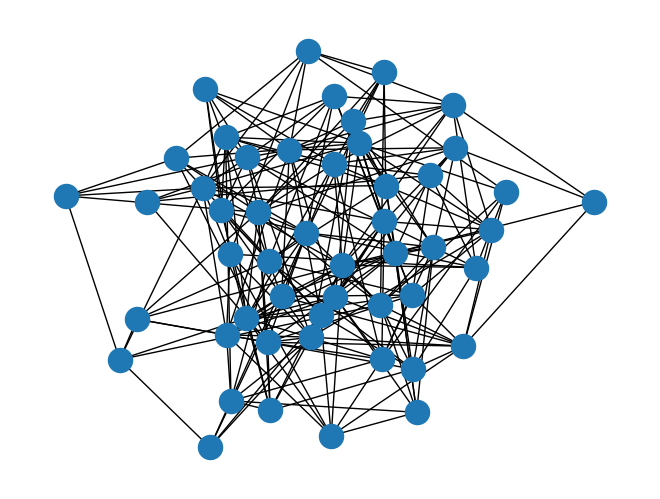

In [ ]:
#Grafo 4
g4 = grafo_erdos_renyi(N5, p5[3], 42)

print("El número de aristas es:", g4.number_of_edges())

print("El grado promedio observado:", (2 * g4.number_of_edges() / g4.number_of_nodes()))

print("El número de componentes conexas es:", len(list(nx.connected_components(g4))))

nx.draw(g4)

**Pregunta conceptual.**

Describa cómo cambia la estructura de la red al aumentar el valor de p.

**R=** Al aumentar p, la conectivididad de la red aumenta, no obstante, el número de componentes conexas disminuye.

## Ejercicio 6. Exploración del número de aristas y del grado promedio.

Fije N = 100 y considere una colección de valores de p en el intervalo [0.01, 0.20].

- Para cada valor de p, genere una realización del grafo aleatorio G(N, p).
- Calcule para cada caso:
    - el número de aristas L,
    - el grado promedio observado.
- Grafique el número de aristas observado en función de p.
- Grafique el grado promedio observado en función de p.
- Compare los resultados con las expresiones teóricas:

In [ ]:
N6 = 100
p6 = np.linspace(0.01, 0.20, 20)

no_aristas = []
grad_prom = []

for i in p6:
    G = grafo_erdos_renyi(N6, i, 42)
    m = G.number_of_edges()
    c = (2 * m) / N6

    no_aristas.append(m)
    grad_prom.append(c)

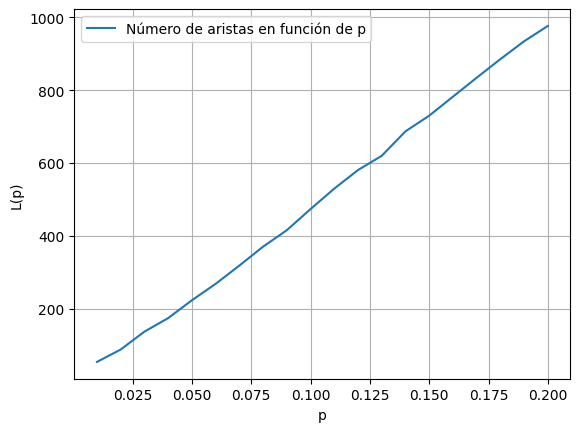

In [ ]:
plt.plot(p6, no_aristas, label="Número de aristas en función de p")
plt.xlabel("p")
plt.ylabel("L(p)")
plt.legend()
plt.grid(True)
plt.show()

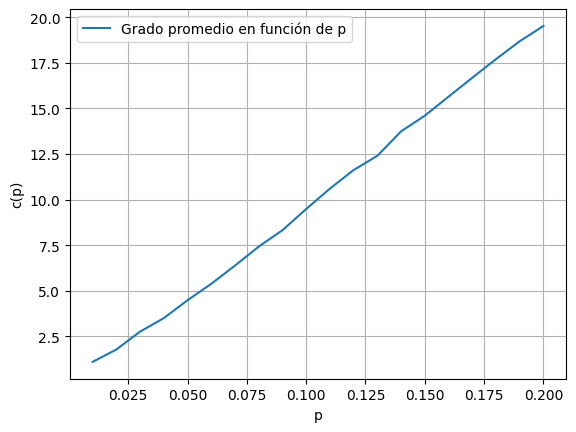

In [ ]:
plt.plot(p6, grad_prom, label="Grado promedio en función de p")
plt.xlabel("p")
plt.ylabel("c(p)")
plt.legend()
plt.grid(True)
plt.show()

**Pregunta conceptual.**

¿De qué manera dependen el número esperado de aristas y el grado promedio esperado del parámetro p?

**R=** Ambos números dependen de manera lineal del parámetro p.